# DINOv2 True Zero-Shot Baseline — Cosine-Similarity Nearest Centroid

A **parameter-free** baseline: no weights are trained at all. We classify test images by comparing their frozen DINOv2 [CLS] features to class centroids via cosine similarity.

**Protocol:** Hold out 10% test set → extract features once (frozen backbone) → 5-fold CV on remaining 90% → each fold: compute class centroids from fold-train features → classify fold-val and test by nearest centroid (cosine similarity) → ensemble test predictions by averaging across folds.

We test DINOv2-Base (ViT-B/14) and DINOv2-Small (ViT-S/14).

**Classifier:** For each test sample, compute cosine similarity to the benign and malignant centroids, then apply softmax to obtain P(malignant). The threshold is tuned for ≥95% sensitivity.

**Binary labels:**
| Original Class | Binary Label |
|---|---|
| Melanoma | **Malignant** (1) |
| BCC | **Malignant** (1) |
| SCC | **Malignant** (1) |
| Actinic Keratosis | **Malignant** (1) |
| Malignant_Other | **Malignant** (1) |
| Melanocytic_Nevus | **Benign** (0) |
| Seborrheic_Keratosis | **Benign** (0) |
| Dermatofibroma | **Benign** (0) |
| Hemangioma | **Benign** (0) |
| Fibrous_Papule | **Benign** (0) |
| Other_Benign | **Benign** (0) |

## 1. Setup & Imports

In [14]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, precision_recall_fscore_support, fbeta_score
)

print("Imports complete.")

Imports complete.


In [15]:
# ── Configuration ──
IMAGES_DIR = "../DataCleaning/Images"
MANIFEST_PATH = "../DataCleaning/instances.csv"
BATCH_SIZE = 32
NUM_CLASSES = 2
SEED = 42
K_FOLDS = 5

CLASS_NAMES = ["Benign", "Malignant"]
MIN_SENSITIVITY_TARGET = 0.95

BINARY_MAP = {
    # Malignant (label = 1)
    "Melanoma": 1,
    "BCC": 1,
    "SCC": 1,
    "Actinic_Keratosis": 1,
    "Malignant_Other": 1,
    # Benign (label = 0)
    "Melanocytic_Nevus": 0,
    "Seborrheic_Keratosis": 0,
    "Dermatofibroma": 0,
    "Hemangioma": 0,
    "Fibrous_Papule": 0,
    "Other_Benign": 0,
    # Note: Uncertain_Melanocytic, Other_Inflammatory, and Unclassified
    # were excluded during preprocessing (see EXCLUSION_ANALYSIS.md)
}

NUM_WORKERS = 0 if os.name == "nt" else min(os.cpu_count() or 8, 12)

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"\n\U0001F52C TRUE ZERO-SHOT BASELINE — {K_FOLDS}-FOLD CROSS-VALIDATION")
print(f"  \u2022 Cosine-similarity nearest-centroid classifier")
print(f"  \u2022 No learned parameters — purely distance-based")
print(f"  \u2022 Compare: DINOv2-Base (ViT-B/14) vs DINOv2-Small (ViT-S/14)")

if torch.cuda.is_available():
    print(f"\nGPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using: cuda
PyTorch: 2.5.1+cu121

🔬 TRUE ZERO-SHOT BASELINE — 5-FOLD CROSS-VALIDATION
  • Cosine-similarity nearest-centroid classifier
  • No learned parameters — purely distance-based
  • Compare: DINOv2-Base (ViT-B/14) vs DINOv2-Small (ViT-S/14)

GPU: NVIDIA GeForce RTX 4060
GPU Memory: 8.6 GB


## 2. Dataset Class (Dermoscope-Only)

In [16]:
class BinaryDermoscopeSkinDataset(Dataset):
    """Dermoscope-only dataset for feature extraction."""
    def __init__(self, manifest_df, images_dir, transform=None):
        self.images_dir = images_dir
        self.transform = transform
        self.samples = []

        for _, row in manifest_df.iterrows():
            label = row["binary_label"]
            for filename in str(row["dscope_files"]).split(";"):
                filepath = os.path.join(images_dir, filename)
                self.samples.append((filepath, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

print("Dataset class defined.")

Dataset class defined.


## 3. Transforms (No Augmentation)

In [17]:
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("Transform created (center crop only, no augmentation)")

Transform created (center crop only, no augmentation)


## 4. Load Data & Test Holdout

In [18]:
manifest = pd.read_csv(MANIFEST_PATH)
print(f"Total instances: {len(manifest)}")
print(f"\nOriginal class distribution:")
print(manifest["cancer_type"].value_counts())

print(f"\nBinary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(manifest)
    print(f"  {name} ({lbl}): {count} ({pct:.1f}%)")

# 10% test holdout (same seed as fine-tuning experiments)
sss_test = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
trainval_idx, test_idx = next(sss_test.split(manifest, manifest["binary_label"]))

trainval_manifest = manifest.iloc[trainval_idx].reset_index(drop=True)
test_manifest = manifest.iloc[test_idx].reset_index(drop=True)

print(f"\nStratified split: TrainVal {len(trainval_manifest)} | Test {len(test_manifest)}")

print(f"\nTrainVal binary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (trainval_manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(trainval_manifest)
    print(f"  {name}: {count} ({pct:.1f}%)")

print(f"\nTest binary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (test_manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(test_manifest)
    print(f"  {name}: {count} ({pct:.1f}%)")

Total instances: 906

Original class distribution:
cancer_type
BCC                     200
Melanocytic_Nevus       190
Other_Benign            138
SCC                     123
Seborrheic_Keratosis     79
Melanoma                 77
Actinic_Keratosis        63
Dermatofibroma           16
Hemangioma               10
Fibrous_Papule            6
Malignant_Other           4
Name: count, dtype: int64

Binary distribution:
  Benign (0): 439 (48.5%)
  Malignant (1): 467 (51.5%)

Stratified split: TrainVal 815 | Test 91

TrainVal binary distribution:
  Benign: 395 (48.5%)
  Malignant: 420 (51.5%)

Test binary distribution:
  Benign: 44 (48.4%)
  Malignant: 47 (51.6%)


## 5. Create Datasets & Loaders

In [19]:
trainval_dataset = BinaryDermoscopeSkinDataset(trainval_manifest, IMAGES_DIR, transform=eval_transform)
test_dataset = BinaryDermoscopeSkinDataset(test_manifest, IMAGES_DIR, transform=eval_transform)

loader_kwargs = {'num_workers': NUM_WORKERS, 'pin_memory': True} if torch.cuda.is_available() else {}
trainval_loader = DataLoader(trainval_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print(f"Datasets: TrainVal {len(trainval_dataset)} | Test {len(test_dataset)}")
print(f"Batches:  TrainVal {len(trainval_loader)} | Test {len(test_loader)}")

Datasets: TrainVal 822 | Test 91
Batches:  TrainVal 26 | Test 3


## 6. Instance-to-Sample Mapping (for KFold)

In [20]:
# Build instance → sample index mapping for KFold splitting
# Each manifest row may have multiple dermoscope images (split by ";")
instance_to_samples = []
idx = 0
for _, row in trainval_manifest.iterrows():
    n_files = len(str(row["dscope_files"]).split(";"))
    instance_to_samples.append(list(range(idx, idx + n_files)))
    idx += n_files

print(f"Instance-to-sample mapping: {len(instance_to_samples)} instances -> {idx} samples")

Instance-to-sample mapping: 815 instances -> 822 samples


## 7. Load DINOv2 Backbones (Base & Small)

In [21]:
print("Loading DINOv2 backbones...")

dinov2_base = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
dinov2_small = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')

for model in [dinov2_base, dinov2_small]:
    model.to(DEVICE).eval()
    for param in model.parameters():
        param.requires_grad = False

embed_dim_base = dinov2_base.embed_dim
embed_dim_small = dinov2_small.embed_dim

print(f"\n\u2713 DINOv2-Base  (ViT-B/14): embed_dim={embed_dim_base}")
print(f"\u2713 DINOv2-Small (ViT-S/14): embed_dim={embed_dim_small}")
print(f"\nAll backbones frozen — feature extraction only")

Loading DINOv2 backbones...


Using cache found in C:\Users\Reyna/.cache\torch\hub\facebookresearch_dinov2_main
Using cache found in C:\Users\Reyna/.cache\torch\hub\facebookresearch_dinov2_main



✓ DINOv2-Base  (ViT-B/14): embed_dim=768
✓ DINOv2-Small (ViT-S/14): embed_dim=384

All backbones frozen — feature extraction only


## 8. Feature Extraction Function

In [22]:
def extract_features(model, dataloader, desc="Extracting features"):
    """Extract frozen DINOv2 [CLS] features from dataloader."""
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc=desc):
            imgs = imgs.to(DEVICE, non_blocking=True)
            feats = model(imgs)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.vstack(all_features), np.concatenate(all_labels)

print("Feature extraction function defined.")

Feature extraction function defined.


## 9. Cosine-Similarity Nearest-Centroid Classifier

**Algorithm:**
1. L2-normalize all feature vectors
2. Compute class centroids (mean of normalized training features per class), then re-normalize
3. For each test sample, compute cosine similarity to both centroids
4. Apply softmax to get P(malignant)

This is **parameter-free** — no optimization, no learned weights.

In [23]:
def cosine_nearest_centroid(train_feats, train_labels, query_feats):
    """
    Nearest-centroid classifier using cosine similarity.
    Returns P(malignant) for each query sample.
    """
    # L2-normalize
    train_norms = np.linalg.norm(train_feats, axis=1, keepdims=True)
    train_normed = train_feats / np.clip(train_norms, 1e-8, None)
    query_norms = np.linalg.norm(query_feats, axis=1, keepdims=True)
    query_normed = query_feats / np.clip(query_norms, 1e-8, None)

    # Class centroids (mean of normalized features, then re-normalize)
    centroid_0 = train_normed[train_labels == 0].mean(axis=0)
    centroid_0 = centroid_0 / np.clip(np.linalg.norm(centroid_0), 1e-8, None)
    centroid_1 = train_normed[train_labels == 1].mean(axis=0)
    centroid_1 = centroid_1 / np.clip(np.linalg.norm(centroid_1), 1e-8, None)

    # Cosine similarity to each centroid
    sim_0 = query_normed @ centroid_0  # (N,)
    sim_1 = query_normed @ centroid_1  # (N,)

    # Softmax over similarities → P(class)
    sims = np.stack([sim_0, sim_1], axis=1)  # (N, 2)
    shifted = sims - sims.max(axis=1, keepdims=True)
    exp_s = np.exp(shifted)
    probs = exp_s / exp_s.sum(axis=1, keepdims=True)

    return probs[:, 1]  # P(malignant)

print("Cosine nearest-centroid classifier defined.")

Cosine nearest-centroid classifier defined.


## 10. Evaluation Utilities

In [24]:
def find_optimal_threshold(y_true, y_probs, min_sensitivity=0.95):
    thresholds = np.arange(0.05, 0.95, 0.01)
    best_threshold = 0.5
    best_sens = 0
    best_spec = 0
    for thresh in thresholds:
        y_pred = (y_probs >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        if sensitivity >= min_sensitivity:
            if specificity > best_spec:
                best_threshold = thresh
                best_sens = sensitivity
                best_spec = specificity
    if best_sens < min_sensitivity:
        for thresh in thresholds:
            y_pred = (y_probs >= thresh).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            if sensitivity > best_sens:
                best_threshold = thresh
                best_sens = sensitivity
                best_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    return best_threshold, best_sens, best_spec


def binary_model_evaluation(y_true, y_probs, class_names, title="",
                           threshold=None, min_sensitivity=0.95):
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    if threshold is None:
        threshold, opt_sens, opt_spec = find_optimal_threshold(
            y_true, y_probs, min_sensitivity=min_sensitivity
        )
        print(f"\n\U0001F3AF Optimal threshold for \u2265{min_sensitivity*100:.0f}% sensitivity: {threshold:.3f}")
        print(f"   At this threshold: Sensitivity={opt_sens:.4f}, Specificity={opt_spec:.4f}")
    y_pred = (y_probs >= threshold).astype(int)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    f2 = fbeta_score(y_true, y_pred, beta=2, average='binary', zero_division=0)
    accuracy = np.mean(y_true == y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    auc_roc = roc_auc_score(y_true, y_probs)
    auc_pr = average_precision_score(y_true, y_probs)
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    print(f"  Classification Threshold: {threshold:.3f}")
    print(f"\n  SENSITIVITY METRICS (Malignant Detection):")
    print(f"    Sensitivity (Recall):  {sensitivity:.4f} {'✓' if sensitivity >= min_sensitivity else '✗'}")
    print(f"    PPV (Precision):       {ppv:.4f}")
    print(f"    F2 Score:              {f2:.4f}")
    print(f"\n  OVERALL METRICS:")
    print(f"    Accuracy:              {accuracy:.4f}")
    print(f"    Specificity:           {specificity:.4f}")
    print(f"    NPV:                   {npv:.4f}")
    print(f"    F1 Score:              {f1:.4f}")
    print(f"    AUC-ROC:               {auc_roc:.4f}")
    print(f"    AUC-PR:                {auc_pr:.4f}")
    print(f"{'='*70}")
    print(f"\n  Confusion Matrix:")
    print(f"    TN={tn:<4} FP={fp:<4}")
    print(f"    FN={fn:<4} TP={tp:<4}")
    print(f"\n{classification_report(y_true, y_pred, target_names=class_names)}")
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title(f"Confusion Matrix\nThreshold={threshold:.3f}")
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    axes[1].plot(fpr, tpr, lw=2, color='darkorange', label=f'ROC (AUC = {auc_roc:.4f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    y_pred_op = (y_probs >= threshold).astype(int)
    tn_op, fp_op, fn_op, tp_op = confusion_matrix(y_true, y_pred_op).ravel()
    fpr_op = fp_op / (fp_op + tn_op) if (fp_op + tn_op) > 0 else 0
    tpr_op = tp_op / (tp_op + fn_op) if (tp_op + fn_op) > 0 else 0
    axes[1].plot(fpr_op, tpr_op, 'ro', markersize=10,
                label=f'Operating Point\n(Sens={tpr_op:.3f})')
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_probs)
    axes[2].plot(rec_curve, prec_curve, lw=2, color='green', label=f'PR (AP = {auc_pr:.4f})')
    axes[2].plot(tpr_op, ppv, 'ro', markersize=10,
                label=f'Operating Point\n(Rec={tpr_op:.3f}, Prec={ppv:.3f})')
    axes[2].set_xlabel("Recall (Sensitivity)")
    axes[2].set_ylabel("Precision (PPV)")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].legend(loc="best")
    axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return {
        "threshold": threshold, "accuracy": accuracy, "precision": precision,
        "recall": recall, "sensitivity": sensitivity, "specificity": specificity,
        "ppv": ppv, "npv": npv, "f1": f1, "f2": f2,
        "auc_roc": auc_roc, "auc_pr": auc_pr,
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
    }

print("Evaluation utilities defined.")

Evaluation utilities defined.


## 11. Extract Features (Once Per Model)

Since backbones are frozen, features are deterministic — we extract once and reuse across all folds.

In [25]:
print("Extracting features from all models...\n")

# Base
base_tv_feats, tv_labels = extract_features(dinov2_base, trainval_loader, "Base: TrainVal")
base_test_feats, test_labels = extract_features(dinov2_base, test_loader, "Base: Test")
print(f"  Base TrainVal: {base_tv_feats.shape} | Test: {base_test_feats.shape}")

# Small
small_tv_feats, _ = extract_features(dinov2_small, trainval_loader, "Small: TrainVal")
small_test_feats, _ = extract_features(dinov2_small, test_loader, "Small: Test")
print(f"  Small TrainVal: {small_tv_feats.shape} | Test: {small_test_feats.shape}")

print(f"\n\u2713 All features extracted. Labels shape: {tv_labels.shape}")

Extracting features from all models...



Base: TrainVal:   0%|          | 0/26 [00:00<?, ?it/s]

Base: Test:   0%|          | 0/3 [00:00<?, ?it/s]

  Base TrainVal: (822, 768) | Test: (91, 768)


Small: TrainVal:   0%|          | 0/26 [00:00<?, ?it/s]

Small: Test:   0%|          | 0/3 [00:00<?, ?it/s]

  Small TrainVal: (822, 384) | Test: (91, 384)

✓ All features extracted. Labels shape: (822,)


## 12. 5-Fold CV — DINOv2-Base

In [26]:
print(f"\n{'='*70}")
print(f"  DINOv2-BASE — {K_FOLDS}-Fold Nearest-Centroid")
print(f"{'='*70}")

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

base_fold_val_metrics = []
base_fold_test_probs = []

for fold, (train_inst_idx, val_inst_idx) in enumerate(skf.split(trainval_manifest, trainval_manifest["binary_label"])):
    print(f"\n--- Fold {fold+1}/{K_FOLDS} ---")

    # Map instance indices to sample (image) indices
    train_samp_idx = [i for inst in train_inst_idx for i in instance_to_samples[inst]]
    val_samp_idx = [i for inst in val_inst_idx for i in instance_to_samples[inst]]

    fold_train_feats = base_tv_feats[train_samp_idx]
    fold_train_labels = tv_labels[train_samp_idx]
    fold_val_feats = base_tv_feats[val_samp_idx]
    fold_val_labels = tv_labels[val_samp_idx]

    print(f"  Train: {len(train_samp_idx)} samples | Val: {len(val_samp_idx)} samples")

    # Nearest-centroid classification
    val_probs = cosine_nearest_centroid(fold_train_feats, fold_train_labels, fold_val_feats)
    test_probs = cosine_nearest_centroid(fold_train_feats, fold_train_labels, base_test_feats)

    # Val metrics
    val_auc = roc_auc_score(fold_val_labels, val_probs)
    val_pred = (val_probs >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(fold_val_labels, val_pred).ravel()
    val_sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    val_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    val_acc = np.mean(fold_val_labels == val_pred)

    base_fold_val_metrics.append({
        'fold': fold + 1, 'auc_roc': val_auc, 'sensitivity': val_sens,
        'specificity': val_spec, 'accuracy': val_acc
    })
    base_fold_test_probs.append(test_probs)

    print(f"  Val AUC={val_auc:.4f} | Sens={val_sens:.4f} | Spec={val_spec:.4f} | Acc={val_acc:.4f}")

# Fold summary
fold_df = pd.DataFrame(base_fold_val_metrics)
print(f"\n{'='*70}")
print("BASE — Per-Fold Validation Results:")
print(fold_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f"\nMean \u00b1 Std:")
for col in ['auc_roc', 'sensitivity', 'specificity', 'accuracy']:
    vals = fold_df[col]
    print(f"  {col}: {vals.mean():.4f} \u00b1 {vals.std():.4f}")


  DINOv2-BASE — 5-Fold Nearest-Centroid

--- Fold 1/5 ---
  Train: 658 samples | Val: 164 samples
  Val AUC=0.7585 | Sens=0.6786 | Spec=0.7250 | Acc=0.7012

--- Fold 2/5 ---
  Train: 658 samples | Val: 164 samples
  Val AUC=0.6271 | Sens=0.6353 | Spec=0.6582 | Acc=0.6463

--- Fold 3/5 ---
  Train: 657 samples | Val: 165 samples
  Val AUC=0.8256 | Sens=0.8118 | Spec=0.7375 | Acc=0.7758

--- Fold 4/5 ---
  Train: 657 samples | Val: 165 samples
  Val AUC=0.7741 | Sens=0.6977 | Spec=0.7089 | Acc=0.7030

--- Fold 5/5 ---
  Train: 658 samples | Val: 164 samples
  Val AUC=0.7133 | Sens=0.6235 | Spec=0.6709 | Acc=0.6463

BASE — Per-Fold Validation Results:
 fold  auc_roc  sensitivity  specificity  accuracy
    1   0.7585       0.6786       0.7250    0.7012
    2   0.6271       0.6353       0.6582    0.6463
    3   0.8256       0.8118       0.7375    0.7758
    4   0.7741       0.6977       0.7089    0.7030
    5   0.7133       0.6235       0.6709    0.6463

Mean ± Std:
  auc_roc: 0.7397 ± 0.0

## 13. Base — Ensemble Test Evaluation


Ensemble of 5 folds — evaluating on held-out test set...

🎯 Optimal threshold for ≥95% sensitivity: 0.480
   At this threshold: Sensitivity=1.0000, Specificity=0.0227

  DINOv2-Base True Zero-Shot (Nearest Centroid) — Ensemble Test
  Classification Threshold: 0.480

  SENSITIVITY METRICS (Malignant Detection):
    Sensitivity (Recall):  1.0000 ✓
    PPV (Precision):       0.5222
    F2 Score:              0.8453

  OVERALL METRICS:
    Accuracy:              0.5275
    Specificity:           0.0227
    NPV:                   1.0000
    F1 Score:              0.6861
    AUC-ROC:               0.7766
    AUC-PR:                0.7426

  Confusion Matrix:
    TN=1    FP=43  
    FN=0    TP=47  

              precision    recall  f1-score   support

      Benign       1.00      0.02      0.04        44
   Malignant       0.52      1.00      0.69        47

    accuracy                           0.53        91
   macro avg       0.76      0.51      0.37        91
weighted avg       0.75  

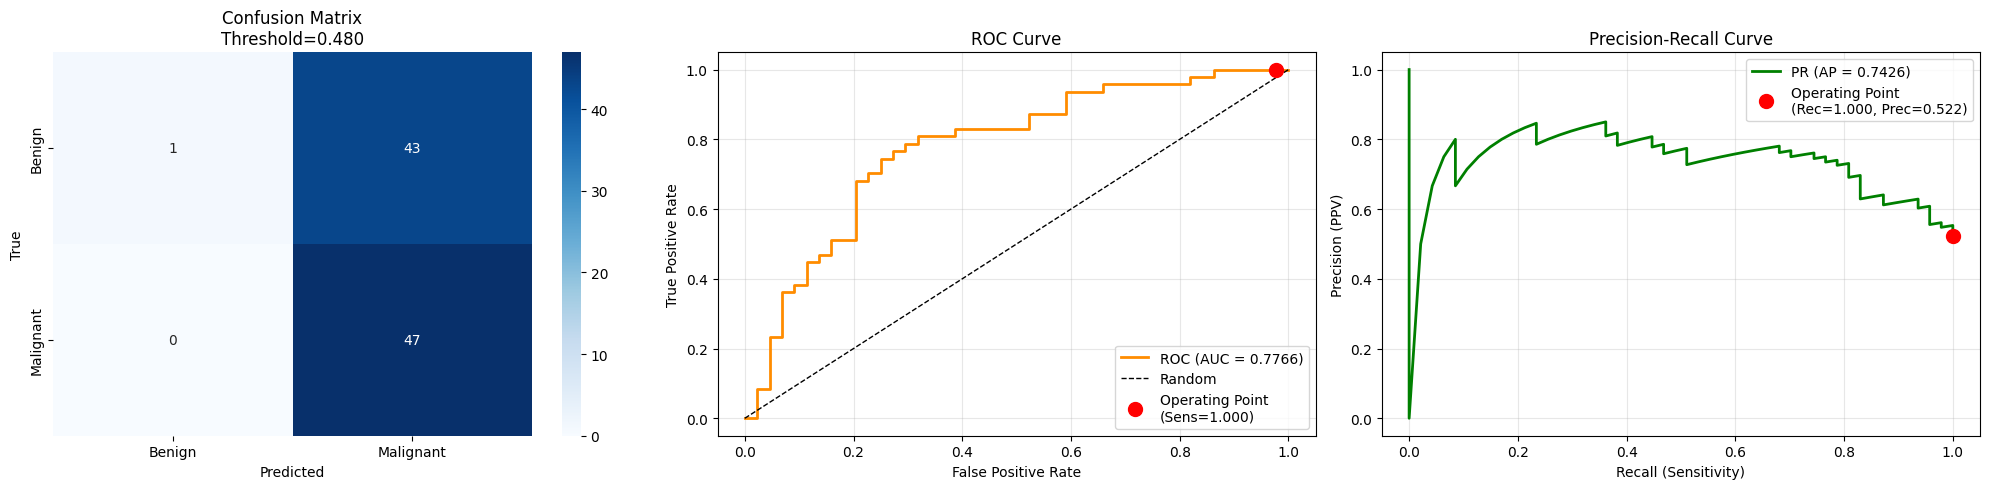

In [27]:
# Ensemble: average test probabilities across folds
base_ensemble_probs = np.mean(np.stack(base_fold_test_probs), axis=0)

print(f"\nEnsemble of {K_FOLDS} folds — evaluating on held-out test set...")

base_results = binary_model_evaluation(
    test_labels, base_ensemble_probs, CLASS_NAMES,
    title="DINOv2-Base True Zero-Shot (Nearest Centroid) — Ensemble Test",
    threshold=None,
    min_sensitivity=MIN_SENSITIVITY_TARGET
)

## 14. 5-Fold CV — DINOv2-Small

In [28]:
print(f"\n{'='*70}")
print(f"  DINOv2-SMALL — {K_FOLDS}-Fold Nearest-Centroid")
print(f"{'='*70}")

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

small_fold_val_metrics = []
small_fold_test_probs = []

for fold, (train_inst_idx, val_inst_idx) in enumerate(skf.split(trainval_manifest, trainval_manifest["binary_label"])):
    print(f"\n--- Fold {fold+1}/{K_FOLDS} ---")

    # Map instance indices to sample (image) indices
    train_samp_idx = [i for inst in train_inst_idx for i in instance_to_samples[inst]]
    val_samp_idx = [i for inst in val_inst_idx for i in instance_to_samples[inst]]

    fold_train_feats = small_tv_feats[train_samp_idx]
    fold_train_labels = tv_labels[train_samp_idx]
    fold_val_feats = small_tv_feats[val_samp_idx]
    fold_val_labels = tv_labels[val_samp_idx]

    print(f"  Train: {len(train_samp_idx)} samples | Val: {len(val_samp_idx)} samples")

    # Nearest-centroid classification
    val_probs = cosine_nearest_centroid(fold_train_feats, fold_train_labels, fold_val_feats)
    test_probs = cosine_nearest_centroid(fold_train_feats, fold_train_labels, small_test_feats)

    # Val metrics
    val_auc = roc_auc_score(fold_val_labels, val_probs)
    val_pred = (val_probs >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(fold_val_labels, val_pred).ravel()
    val_sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    val_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    val_acc = np.mean(fold_val_labels == val_pred)

    small_fold_val_metrics.append({
        'fold': fold + 1, 'auc_roc': val_auc, 'sensitivity': val_sens,
        'specificity': val_spec, 'accuracy': val_acc
    })
    small_fold_test_probs.append(test_probs)

    print(f"  Val AUC={val_auc:.4f} | Sens={val_sens:.4f} | Spec={val_spec:.4f} | Acc={val_acc:.4f}")

# Fold summary
fold_df = pd.DataFrame(small_fold_val_metrics)
print(f"\n{'='*70}")
print("SMALL — Per-Fold Validation Results:")
print(fold_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f"\nMean \u00b1 Std:")
for col in ['auc_roc', 'sensitivity', 'specificity', 'accuracy']:
    vals = fold_df[col]
    print(f"  {col}: {vals.mean():.4f} \u00b1 {vals.std():.4f}")


  DINOv2-SMALL — 5-Fold Nearest-Centroid

--- Fold 1/5 ---
  Train: 658 samples | Val: 164 samples
  Val AUC=0.7909 | Sens=0.7262 | Spec=0.7500 | Acc=0.7378

--- Fold 2/5 ---
  Train: 658 samples | Val: 164 samples
  Val AUC=0.6622 | Sens=0.6118 | Spec=0.5696 | Acc=0.5915

--- Fold 3/5 ---
  Train: 657 samples | Val: 165 samples
  Val AUC=0.8232 | Sens=0.7294 | Spec=0.7750 | Acc=0.7515

--- Fold 4/5 ---
  Train: 657 samples | Val: 165 samples
  Val AUC=0.7823 | Sens=0.7674 | Spec=0.6329 | Acc=0.7030

--- Fold 5/5 ---
  Train: 658 samples | Val: 164 samples
  Val AUC=0.7503 | Sens=0.6471 | Spec=0.7342 | Acc=0.6890

SMALL — Per-Fold Validation Results:
 fold  auc_roc  sensitivity  specificity  accuracy
    1   0.7909       0.7262       0.7500    0.7378
    2   0.6622       0.6118       0.5696    0.5915
    3   0.8232       0.7294       0.7750    0.7515
    4   0.7823       0.7674       0.6329    0.7030
    5   0.7503       0.6471       0.7342    0.6890

Mean ± Std:
  auc_roc: 0.7618 ± 0

## 15. Small — Ensemble Test Evaluation


Ensemble of 5 folds — evaluating on held-out test set...

🎯 Optimal threshold for ≥95% sensitivity: 0.050
   At this threshold: Sensitivity=1.0000, Specificity=0.0000

  DINOv2-Small True Zero-Shot (Nearest Centroid) — Ensemble Test
  Classification Threshold: 0.050

  SENSITIVITY METRICS (Malignant Detection):
    Sensitivity (Recall):  1.0000 ✓
    PPV (Precision):       0.5165
    F2 Score:              0.8423

  OVERALL METRICS:
    Accuracy:              0.5165
    Specificity:           0.0000
    NPV:                   0.0000
    F1 Score:              0.6812
    AUC-ROC:               0.7311
    AUC-PR:                0.6992

  Confusion Matrix:
    TN=0    FP=44  
    FN=0    TP=47  

              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00        44
   Malignant       0.52      1.00      0.68        47

    accuracy                           0.52        91
   macro avg       0.26      0.50      0.34        91
weighted avg       0.27 

c:\Coding\SkinCancerImageClassificationResearch\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Coding\SkinCancerImageClassificationResearch\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Coding\SkinCancerImageClassificationResearch\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

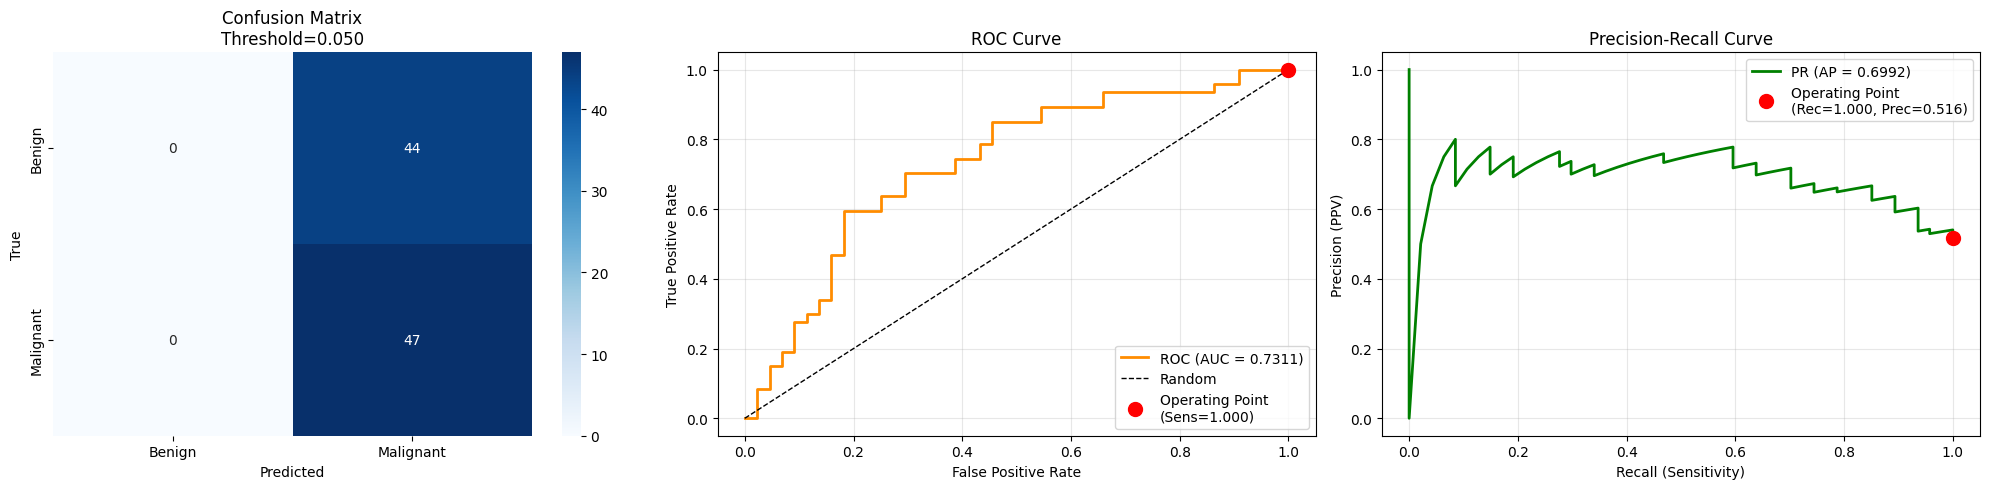

In [29]:
# Ensemble: average test probabilities across folds
small_ensemble_probs = np.mean(np.stack(small_fold_test_probs), axis=0)

print(f"\nEnsemble of {K_FOLDS} folds — evaluating on held-out test set...")

small_results = binary_model_evaluation(
    test_labels, small_ensemble_probs, CLASS_NAMES,
    title="DINOv2-Small True Zero-Shot (Nearest Centroid) — Ensemble Test",
    threshold=None,
    min_sensitivity=MIN_SENSITIVITY_TARGET
)

## 16. Comparison: Base vs Small

In [30]:
print("\n" + "="*80)
print("TRUE ZERO-SHOT COMPARISON: DINOv2-Base vs DINOv2-Small")
print("="*80)

comparison_df = pd.DataFrame({
    'Metric': ['AUC-ROC', 'AUC-PR', 'Sensitivity', 'Specificity', 'Accuracy', 'F1', 'F2', 'PPV', 'NPV'],
    'Base (ViT-B/14)': [
        base_results['auc_roc'], base_results['auc_pr'],
        base_results['sensitivity'], base_results['specificity'],
        base_results['accuracy'], base_results['f1'], base_results['f2'],
        base_results['ppv'], base_results['npv'],
    ],
    'Small (ViT-S/14)': [
        small_results['auc_roc'], small_results['auc_pr'],
        small_results['sensitivity'], small_results['specificity'],
        small_results['accuracy'], small_results['f1'], small_results['f2'],
        small_results['ppv'], small_results['npv'],
    ],
})

comparison_df['Diff (B-S)'] = comparison_df['Base (ViT-B/14)'] - comparison_df['Small (ViT-S/14)']

print("\n" + comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

models = {
    'Base (ViT-B/14)': base_results,
    'Small (ViT-S/14)': small_results,
}
best_model = max(models, key=lambda k: models[k]['auc_roc'])
best_auc = models[best_model]['auc_roc']

print(f"\n\nKey Findings:")
print(f"  \u2022 Best AUC-ROC: {best_model} ({best_auc:.4f})")
for name, res in models.items():
    sens_flag = '\u2713' if res['sensitivity'] >= MIN_SENSITIVITY_TARGET else '\u2717'
    print(f"  \u2022 {name}: AUC-ROC={res['auc_roc']:.4f}, Sensitivity={res['sensitivity']:.4f} {sens_flag}")

print(f"\n  \u2022 Base embed dim:  {embed_dim_base}  (86M backbone params)")
print(f"  \u2022 Small embed dim: {embed_dim_small}  (22M backbone params)")
print(f"  \u2022 Classifier: cosine-similarity nearest centroid (no learned parameters)")
print(f"  \u2022 Ensemble of {K_FOLDS} folds per model")

print("\n" + "="*80)


TRUE ZERO-SHOT COMPARISON: DINOv2-Base vs DINOv2-Small

     Metric  Base (ViT-B/14)  Small (ViT-S/14)  Diff (B-S)
    AUC-ROC           0.7766            0.7311      0.0455
     AUC-PR           0.7426            0.6992      0.0435
Sensitivity           1.0000            1.0000      0.0000
Specificity           0.0227            0.0000      0.0227
   Accuracy           0.5275            0.5165      0.0110
         F1           0.6861            0.6812      0.0050
         F2           0.8453            0.8423      0.0030
        PPV           0.5222            0.5165      0.0057
        NPV           1.0000            0.0000      1.0000


Key Findings:
  • Best AUC-ROC: Base (ViT-B/14) (0.7766)
  • Base (ViT-B/14): AUC-ROC=0.7766, Sensitivity=1.0000 ✓
  • Small (ViT-S/14): AUC-ROC=0.7311, Sensitivity=1.0000 ✓

  • Base embed dim:  768  (86M backbone params)
  • Small embed dim: 384  (22M backbone params)
  • Classifier: cosine-similarity nearest centroid (no learned parameters)
  • E

## 17. Visualize Comparison

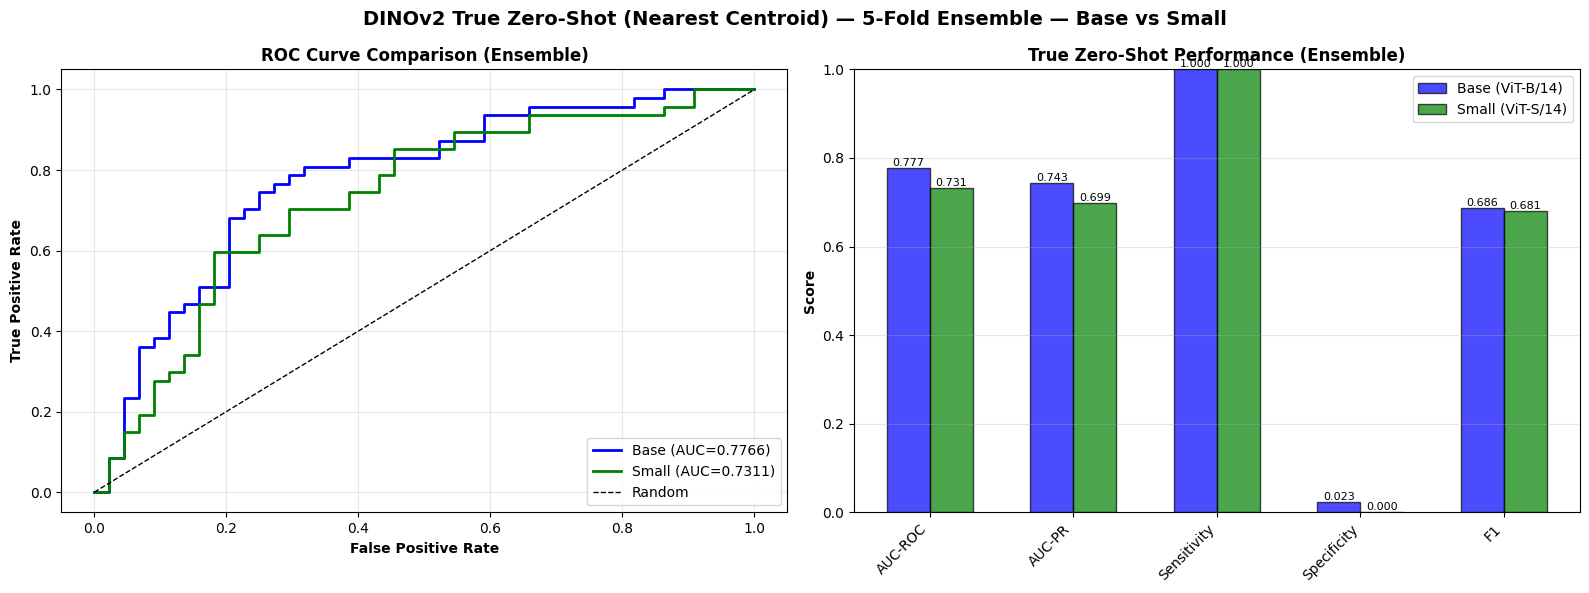

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC comparison
fpr_base, tpr_base, _ = roc_curve(test_labels, base_ensemble_probs)
fpr_small, tpr_small, _ = roc_curve(test_labels, small_ensemble_probs)

axes[0].plot(fpr_base, tpr_base, lw=2, color='blue',
            label=f'Base (AUC={base_results["auc_roc"]:.4f})')
axes[0].plot(fpr_small, tpr_small, lw=2, color='green',
            label=f'Small (AUC={small_results["auc_roc"]:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title('ROC Curve Comparison (Ensemble)', fontweight='bold', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Metrics bar chart
metrics = ['AUC-ROC', 'AUC-PR', 'Sensitivity', 'Specificity', 'F1']
base_vals = [base_results['auc_roc'], base_results['auc_pr'],
             base_results['sensitivity'], base_results['specificity'], base_results['f1']]
small_vals = [small_results['auc_roc'], small_results['auc_pr'],
              small_results['sensitivity'], small_results['specificity'], small_results['f1']]

x = np.arange(len(metrics))
width = 0.3

bars1 = axes[1].bar(x - width/2, base_vals, width, label='Base (ViT-B/14)',
                    color='blue', alpha=0.7, edgecolor='black')
bars2 = axes[1].bar(x + width/2, small_vals, width, label='Small (ViT-S/14)',
                    color='green', alpha=0.7, edgecolor='black')

axes[1].set_ylabel('Score', fontweight='bold')
axes[1].set_title('True Zero-Shot Performance (Ensemble)', fontweight='bold', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_ylim([0, 1])

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'DINOv2 True Zero-Shot (Nearest Centroid) — {K_FOLDS}-Fold Ensemble — Base vs Small',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 18. Results Summary

In [32]:
summary_df = pd.DataFrame([
    {'Model': 'Base (ViT-B/14)', **base_results},
    {'Model': 'Small (ViT-S/14)', **small_results},
])

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY — TRUE ZERO-SHOT (NEAREST CENTROID)")
print("="*80)
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))

print(f"\n\n\u2713 True zero-shot baseline established ({K_FOLDS}-fold ensemble)")
print(f"\nThis is the strictest baseline — no parameters learned at all.")
print(f"Any model that doesn't beat this is not worth fine-tuning.")
print(f"\nNext steps:")
print(f"  1. Compare with linear probe (LogReg on frozen features)")
print(f"  2. Compare with fine-tuned models")
print(f"  3. Quantify: zero-shot < linear probe < fine-tuned")

print(f"\n{'='*80}")
print("EXPERIMENT COMPLETE")
print(f"{'='*80}")


FINAL RESULTS SUMMARY — TRUE ZERO-SHOT (NEAREST CENTROID)
           Model  threshold  accuracy  precision  recall  sensitivity  specificity    ppv    npv     f1     f2  auc_roc  auc_pr  tp  tn  fp  fn
 Base (ViT-B/14)     0.4800    0.5275     0.5222  1.0000       1.0000       0.0227 0.5222 1.0000 0.6861 0.8453   0.7766  0.7426  47   1  43   0
Small (ViT-S/14)     0.0500    0.5165     0.5165  1.0000       1.0000       0.0000 0.5165 0.0000 0.6812 0.8423   0.7311  0.6992  47   0  44   0


✓ True zero-shot baseline established (5-fold ensemble)

This is the strictest baseline — no parameters learned at all.
Any model that doesn't beat this is not worth fine-tuning.

Next steps:
  1. Compare with linear probe (LogReg on frozen features)
  2. Compare with fine-tuned models
  3. Quantify: zero-shot < linear probe < fine-tuned

EXPERIMENT COMPLETE
